
# Intelligent Cybersecurity Framework — CICIDS 2017
### Deep Learning · LLM Agent · XAI · Adversarial Robustness · Zero-Trust
---


## 1. Import Libraries

In [1]:
!pip -q install tensorflow scikit-learn imbalanced-learn shap lime adversarial-robustness-toolbox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.9 MB/s eta 0:00:00


In [2]:
# Standard
import os, warnings, time
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
np.random.seed(42)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, MaxPooling1D, Flatten,
    LSTM, BatchNormalization, Input, MultiHeadAttention,
    GlobalAveragePooling1D, LayerNormalization, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# XAI
import shap
from lime.lime_tabular import LimeTabularExplainer

# Adversarial Robustness Toolbox
from art.estimators.classification import KerasClassifier as ARTKeras
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent

print("Libraries loaded OK")
print(f"TensorFlow {tf.__version__}  |  GPU: {len(tf.config.list_physical_devices('GPU'))>0}")


Libraries loaded OK
TensorFlow 2.20.0  |  GPU: True


In [3]:
# Colab GPU config — enable mixed precision for faster training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# Confirm GPU
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("Memory growth enabled")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled


## 2. Dataset Loading

In [4]:
!unzip /content/CIC_IDS_2017.zip

Archive:  /content/CIC_IDS_2017.zip
  inflating: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  
  inflating: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  
  inflating: Friday-WorkingHours-Morning.pcap_ISCX.csv  
  inflating: Monday-WorkingHours.pcap_ISCX.csv  
  inflating: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  
  inflating: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  
  inflating: Tuesday-WorkingHours.pcap_ISCX.csv  
  inflating: Wednesday-workingHours.pcap_ISCX.csv  


In [6]:

# Paths — adjust DATA_DIR if files are in a subfolder
DATA_DIR = "."

file_map = {
    "Friday_DDoS"        : "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday_PortScan"    : "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday_Morning"     : "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Monday"             : "Monday-WorkingHours.pcap_ISCX.csv",
    "Thursday_Afternoon" : "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Thursday_Morning"   : "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Tuesday"            : "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday"          : "Wednesday-workingHours.pcap_ISCX.csv",
}

dfs = []
for label, fname in file_map.items():
    path = os.path.join(DATA_DIR, fname)
    if os.path.exists(path):
        tmp = pd.read_csv(path, low_memory=False)
        tmp["_src"] = label
        dfs.append(tmp)
        print(f"  OK  {label:22s}  {tmp.shape}")
    else:
        print(f"  MISSING: {path}")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined : {df_raw.shape}")


  OK  Friday_DDoS             (225745, 80)
  OK  Friday_PortScan         (286467, 80)
  OK  Friday_Morning          (191033, 80)
  OK  Monday                  (529918, 80)
  OK  Thursday_Afternoon      (288602, 80)
  OK  Thursday_Morning        (170366, 80)
  OK  Tuesday                 (445909, 80)
  OK  Wednesday               (692703, 80)

Combined : (2830743, 80)


## 3. Data Inspection

In [7]:
# Shape and columns
print("Shape:", df_raw.shape)
print("\nFirst 20 columns:", list(df_raw.columns[:20]))


Shape: (2830743, 80)

First 20 columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min']


In [8]:
# Initial rows
df_raw.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,_src
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday_DDoS
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday_DDoS
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday_DDoS


In [9]:
# Basic data information - Column name, data type
df_raw.info(verbose=False, memory_usage="deep")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Columns: 80 entries,  Destination Port to _src
dtypes: float64(24), int64(54), object(2)
memory usage: 1.9 GB


In [10]:
# Statical Description
df_raw.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.0,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.0,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.0,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.0,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.0,0.000000,0.000000,2.616295e+01,7.125597e+03


In [11]:
# Duplicates and missing values
print("Duplicate rows :", df_raw.duplicated().sum())
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with NaN:")
print(missing if len(missing) else "  None")

Duplicate rows : 256479

Columns with NaN:
Flow Bytes/s    1358
dtype: int64


In [12]:

# Unique attack labels
TARGET_RAW = " Label"   # raw column name (has leading space)
print("Attack label counts:")
print(df_raw[TARGET_RAW].value_counts().to_string())


Attack label counts:
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


## 4. Data Processing (Cleaning)

In [13]:
# Strip whitespace from column names
df_raw.columns = df_raw.columns.str.strip()
TARGET = "Label"

# Drop helper column added during loading
df_raw.drop(columns=["_src"], errors="ignore", inplace=True)

# Remove duplicate rows
df_raw.drop_duplicates(inplace=True)
print(f"After de-dup : {df_raw.shape}")

After de-dup : (2522362, 79)


In [14]:
# Replace Inf / -Inf with NaN, then drop
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
df_raw.dropna(inplace=True)
print(f"After NaN/Inf drop : {df_raw.shape}")

After NaN/Inf drop : (2520798, 79)


In [15]:
# Separate features and label; keep numeric only
X = df_raw.drop(columns=[TARGET]).select_dtypes(include=[np.number])
y = df_raw[TARGET].copy()
print(f"Feature matrix : {X.shape}")
print(f"Unique classes : {y.nunique()}")


Feature matrix : (2520798, 78)
Unique classes : 15


In [16]:

# Encode string labels to integers
le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(le.classes_)
print("Label mapping:")
for i, c in enumerate(le.classes_):
    print(f"  {i:2d}  {c}")


Label mapping:
   0  BENIGN
   1  Bot
   2  DDoS
   3  DoS GoldenEye
   4  DoS Hulk
   5  DoS Slowhttptest
   6  DoS slowloris
   7  FTP-Patator
   8  Heartbleed
   9  Infiltration
  10  PortScan
  11  SSH-Patator
  12  Web Attack � Brute Force
  13  Web Attack � Sql Injection
  14  Web Attack � XSS


In [17]:
# Binary label: BENIGN=0, any attack=1
y_binary = (y != "BENIGN").astype(int).values


## 5. Exploratory Data Analysis (EDA)

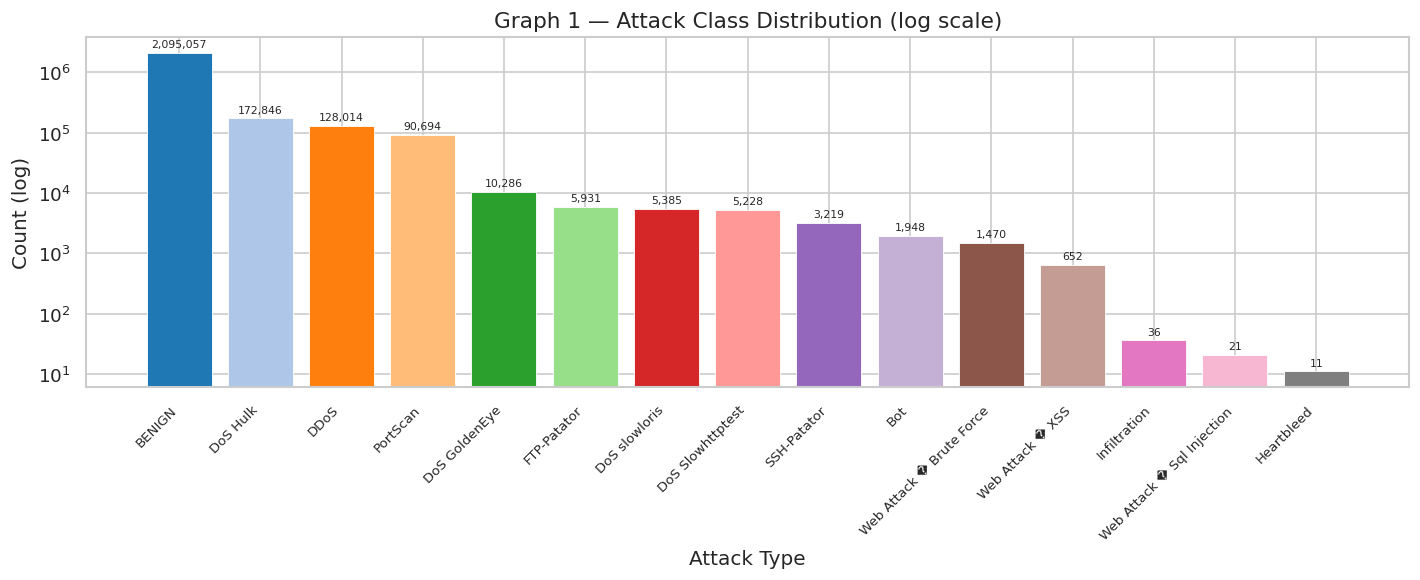

In [18]:
# Graph 1 — Attack class distribution (log scale)
fig, ax = plt.subplots(figsize=(12, 5))
vc = y.value_counts()
colors = sns.color_palette("tab20", len(vc))
bars = ax.bar(range(len(vc)), vc.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(vc)))
ax.set_xticklabels(vc.index, rotation=45, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_title("Graph 1 — Attack Class Distribution (log scale)")
ax.set_ylabel("Count (log)"); ax.set_xlabel("Attack Type")
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.15,
            f"{val:,}", ha="center", va="bottom", fontsize=6.5, rotation=0)
plt.tight_layout(); plt.show()


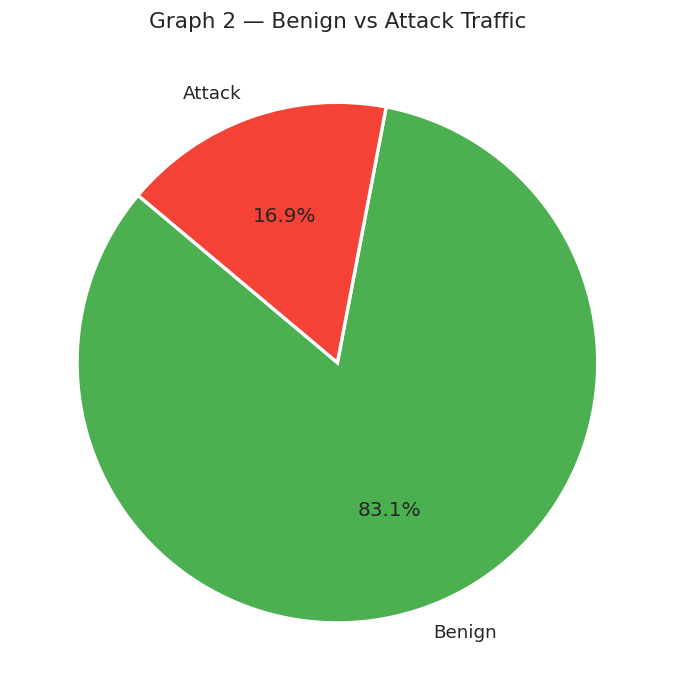

In [19]:
# Graph 2 — Benign vs Attack pie chart
fig, ax = plt.subplots(figsize=(6, 6))
bc = (y == "BENIGN").sum(); ac = (y != "BENIGN").sum()
ax.pie([bc, ac], labels=["Benign", "Attack"],
       autopct="%1.1f%%", colors=["#4CAF50","#F44336"],
       startangle=140, wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Graph 2 — Benign vs Attack Traffic")
plt.tight_layout(); plt.show()


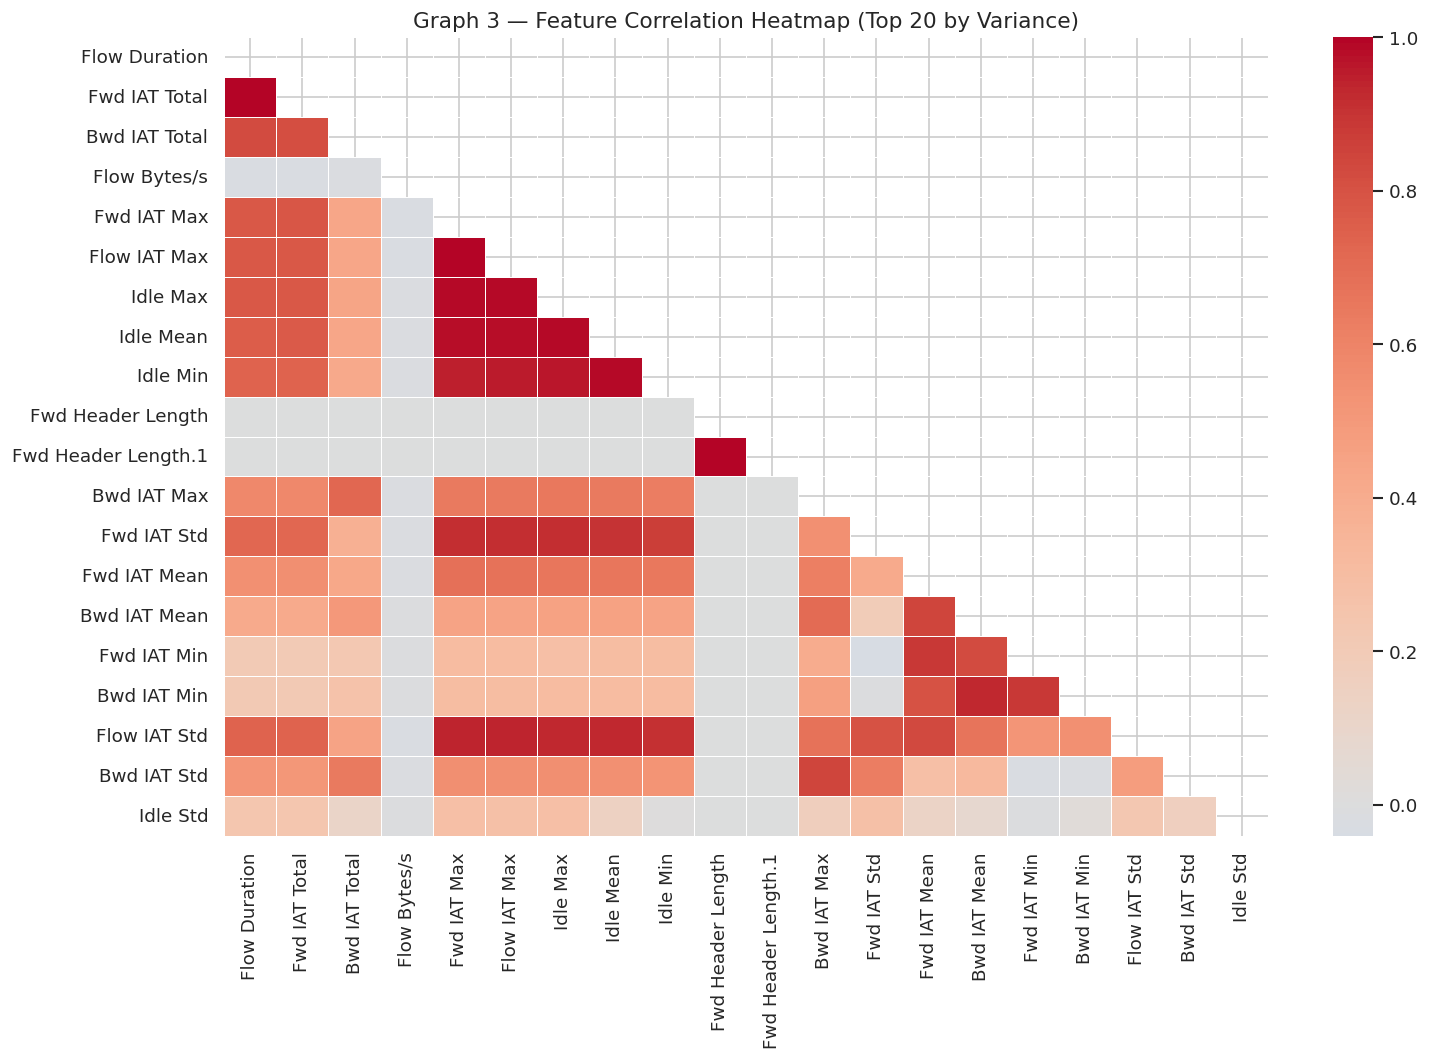

In [20]:
# Graph 3 — Correlation heatmap (top 20 by variance)
top20 = X.var().nlargest(20).index
corr = X[top20].corr()
fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title("Graph 3 — Feature Correlation Heatmap (Top 20 by Variance)")
plt.tight_layout(); plt.show()


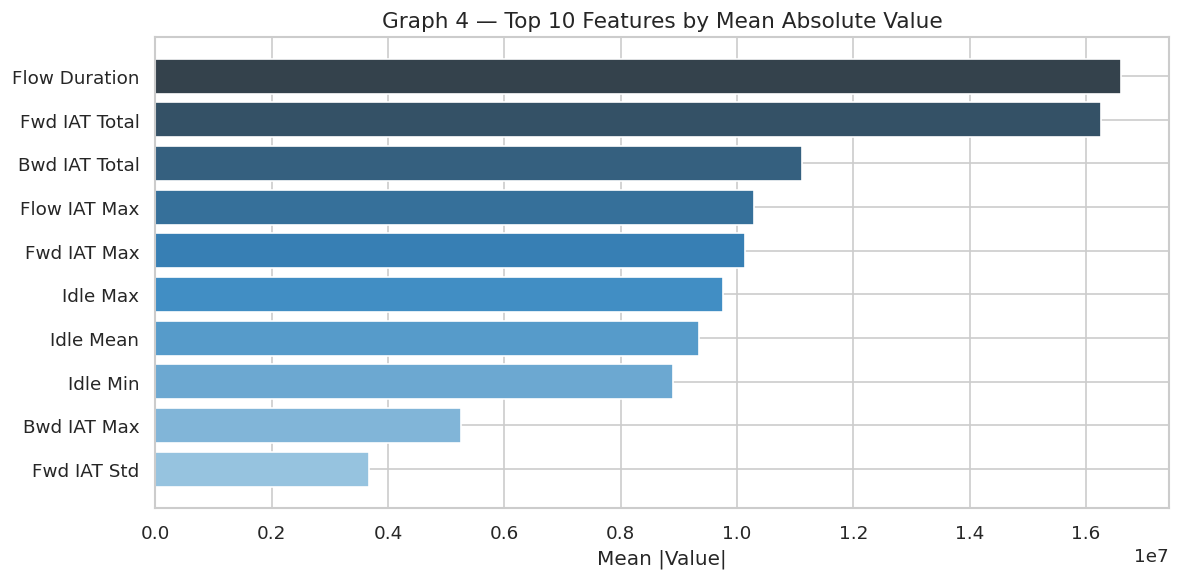

In [21]:
# Graph 4 — Top 10 features by mean absolute value
feat_means = X.abs().mean().nlargest(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feat_means.index[::-1], feat_means.values[::-1],
        color=sns.color_palette("Blues_d", 10))
ax.set_title("Graph 4 — Top 10 Features by Mean Absolute Value")
ax.set_xlabel("Mean |Value|")
plt.tight_layout(); plt.show()


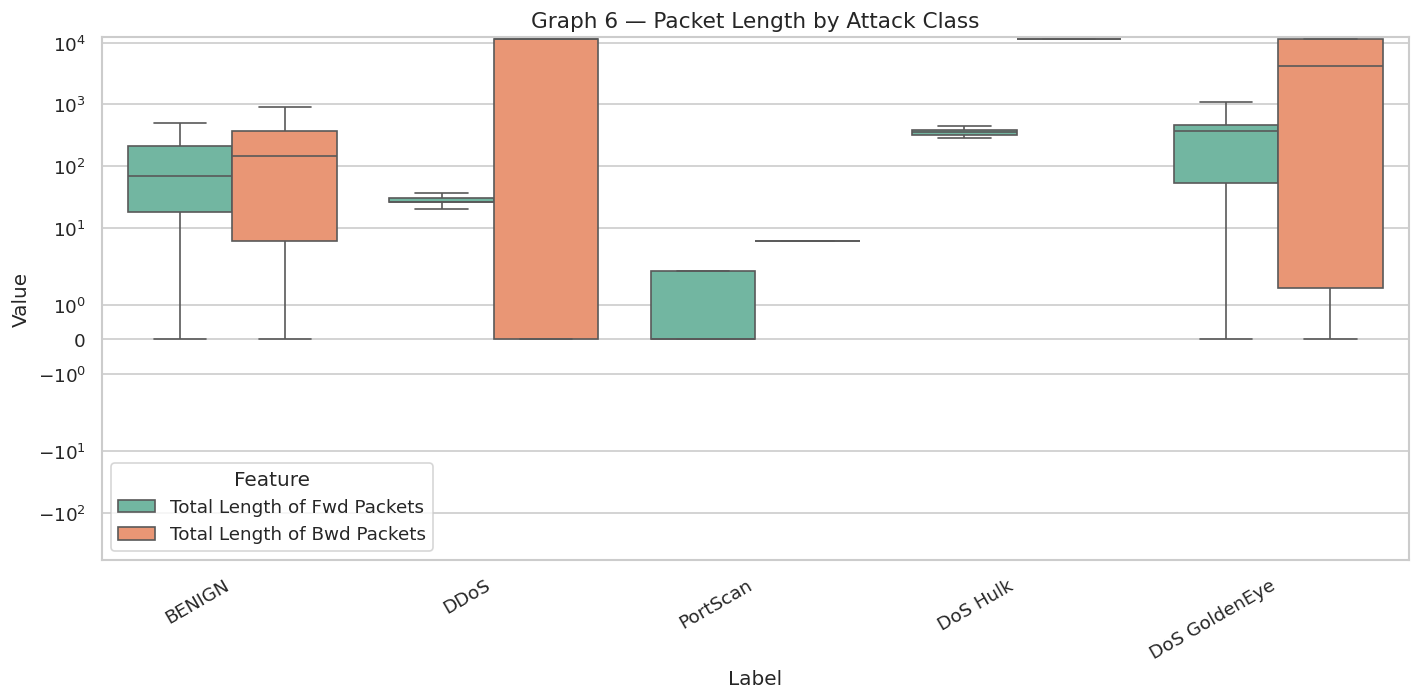

In [23]:
# Graph 5 — Boxplot: Fwd/Bwd packet length vs top attack classes
c1 = "Total Length of Fwd Packets" if "Total Length of Fwd Packets" in X.columns else X.columns[4]
c2 = "Total Length of Bwd Packets" if "Total Length of Bwd Packets" in X.columns else X.columns[5]
df6 = X.loc[mask5, [c1, c2]].copy(); df6["Label"] = y[mask5].values
df6m = df6.melt(id_vars="Label", var_name="Feature", value_name="Value")
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df6m, x="Label", y="Value", hue="Feature",
            ax=ax, showfliers=False, palette="Set2")
ax.set_yscale("symlog"); ax.set_title("Graph 6 — Packet Length by Attack Class")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()


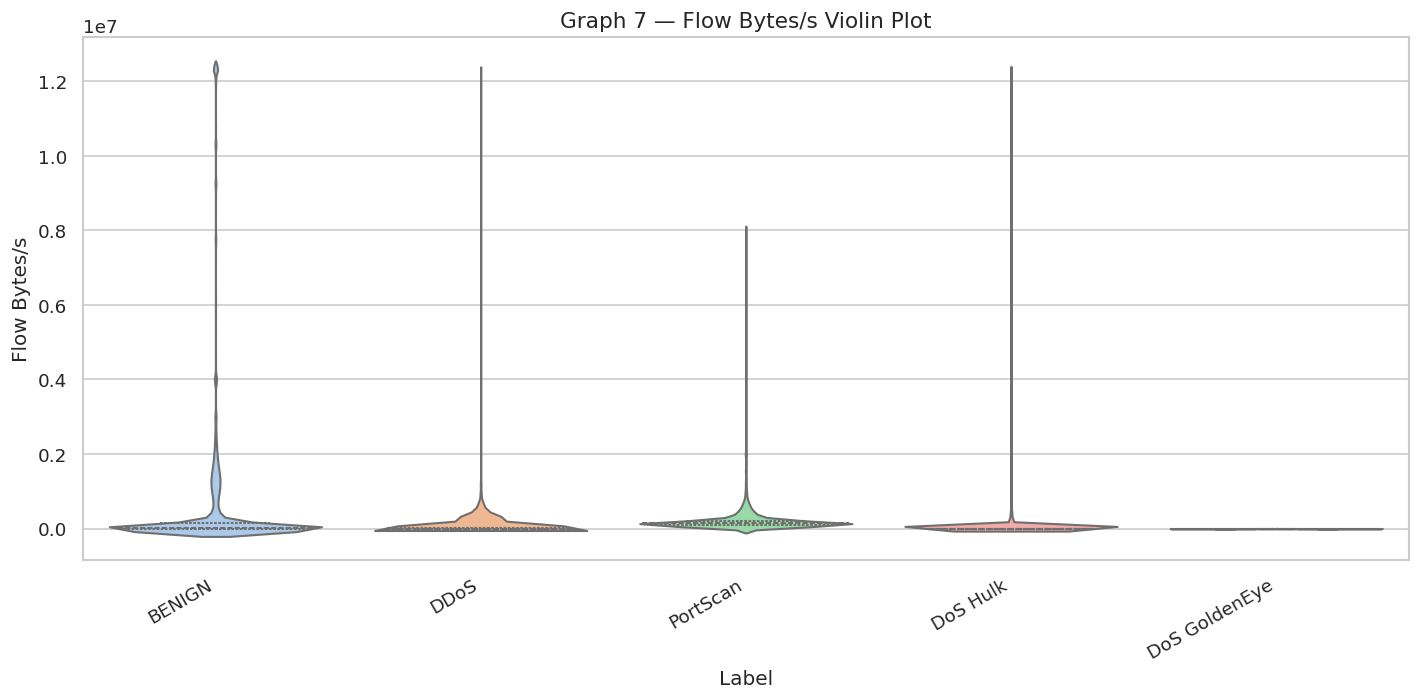

In [24]:

# Graph 6 — Violin plot: Flow Bytes/s
col7 = "Flow Bytes/s" if "Flow Bytes/s" in X.columns else X.columns[10]
df7 = X.loc[mask5, [col7]].copy(); df7["Label"] = y[mask5].values
df7[col7] = df7[col7].clip(0, df7[col7].quantile(0.99))
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df7, x="Label", y=col7, palette="pastel", inner="quartile", ax=ax)
ax.set_title(f"Graph 7 — {col7} Violin Plot")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()


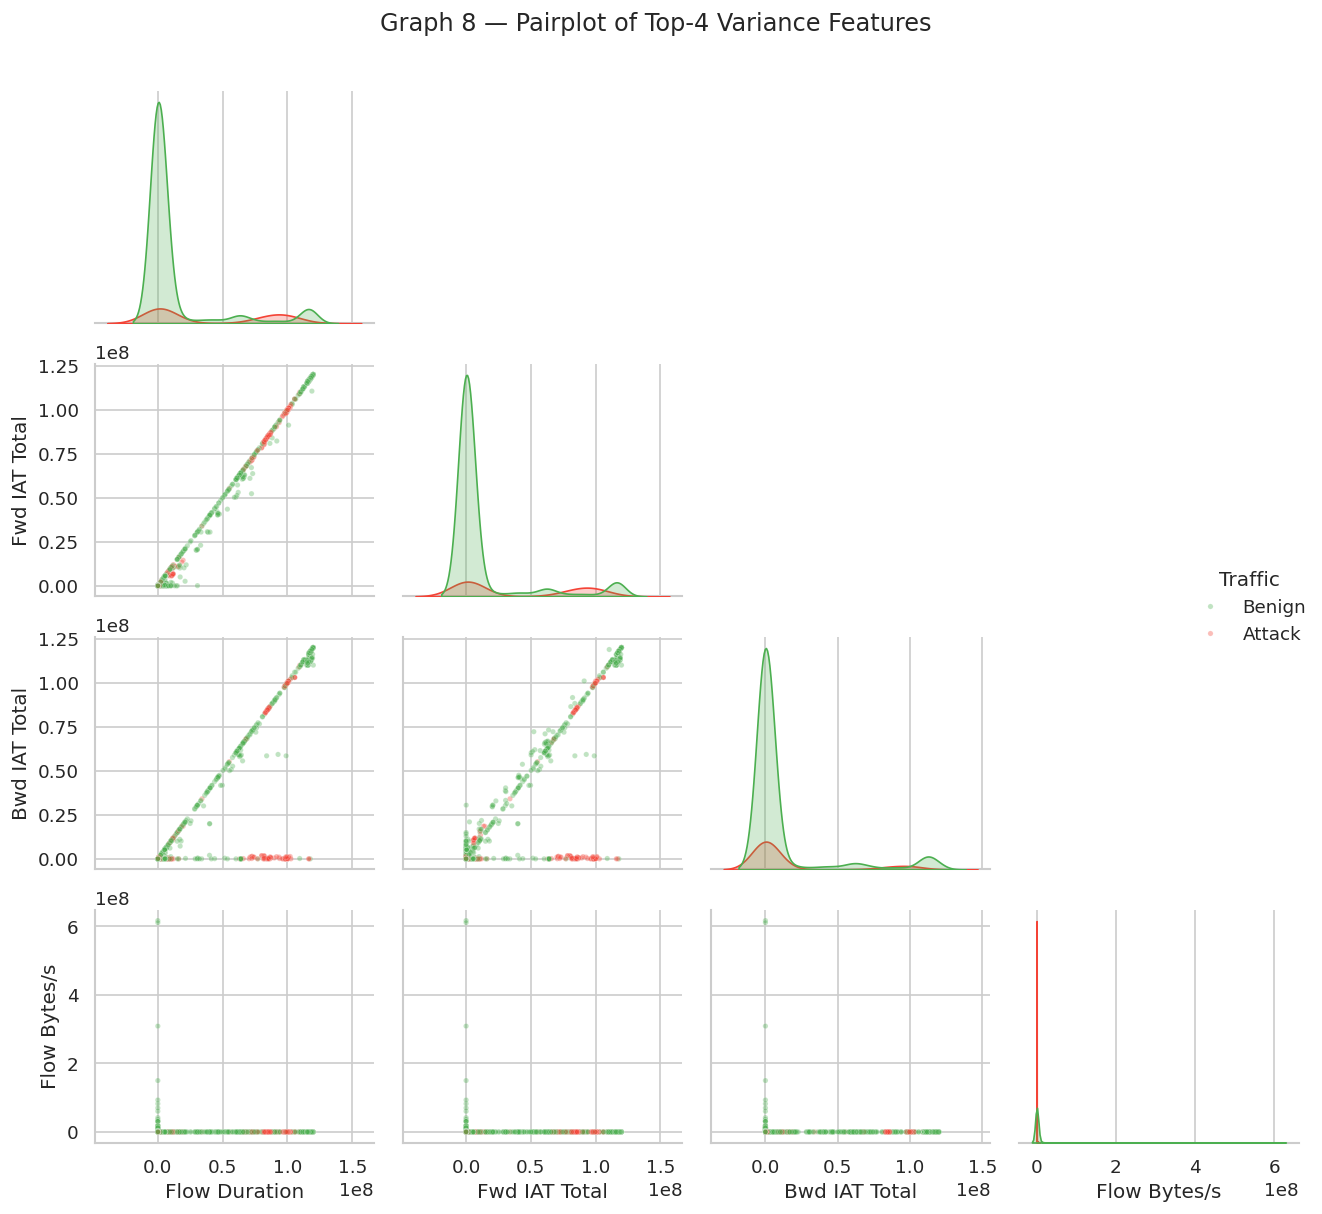

In [25]:
# Graph 7 — Pairplot of top-4 variance features (3000 sample)
top4 = X.var().nlargest(4).index.tolist()
dfp = X[top4].copy(); dfp["Traffic"] = np.where(y=="BENIGN","Benign","Attack")
dfs3k = dfp.sample(min(3000, len(dfp)), random_state=42)
pg = sns.pairplot(dfs3k, hue="Traffic",
                  palette={"Benign":"#4CAF50","Attack":"#F44336"},
                  plot_kws={"alpha":0.35,"s":10}, diag_kind="kde", corner=True)
pg.fig.suptitle("Graph 8 — Pairplot of Top-4 Variance Features", y=1.01)
plt.tight_layout(); plt.show()

## 6. Pre-Processing & Feature Engineering

In [26]:
# Remove near-zero variance columns
low_var = X.var()[X.var() < 1e-4].index.tolist()
X.drop(columns=low_var, errors="ignore", inplace=True)
print(f"Dropped {len(low_var)} low-variance cols. Remaining features: {X.shape[1]}")


Dropped 10 low-variance cols. Remaining features: 68


In [27]:
# Stratified equal sampling — 10k rows per class → ~150k total
SAMPLES_PER_CLASS = 10000

# Reattach label for grouped sampling
df_bal = X.copy()
df_bal["Label"] = y.values

parts = []
for lbl in df_bal["Label"].unique():
    subset = df_bal[df_bal["Label"] == lbl]
    n = min(len(subset), SAMPLES_PER_CLASS)
    parts.append(subset.sample(n, random_state=42))

df_bal = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=42)

In [28]:
# Reassign X and y from balanced frame
X = df_bal.drop(columns=["Label"])
y = df_bal["Label"]

In [29]:
# Re-encode on balanced set
le = LabelEncoder()
y_enc     = le.fit_transform(y)
n_classes = len(le.classes_)
y_binary  = (y != "BENIGN").astype(int).values

print(f"Balanced dataset : {X.shape}")
print("Class counts:")
print(y.value_counts().to_string())

Balanced dataset : (73901, 68)
Class counts:
Label
DoS GoldenEye                 10000
BENIGN                        10000
DDoS                          10000
PortScan                      10000
DoS Hulk                      10000
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack � Brute Force       1470
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11


In [30]:
# Train / Validation / Test split  70 / 10 / 20
X_tr, X_te, y_tr, y_te = train_test_split(
    X.values, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=0.125, random_state=42, stratify=y_tr)
print(f"Train {X_tr.shape}  Val {X_val.shape}  Test {X_te.shape}")

Train (51730, 68)  Val (7390, 68)  Test (14781, 68)


In [31]:
# Standard scaling (fit on train only)
scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te  = scaler.transform(X_te)


In [32]:
print("Training label distribution")
print(pd.Series(y_tr).value_counts().to_string())

Training label distribution
4     7000
10    7000
3     7000
0     7000
2     7000
7     4152
6     3770
5     3659
11    2253
1     1363
12    1029
14     456
9       25
13      15
8        8


In [33]:
# One-hot encode labels for Keras softmax
n_features = X_tr.shape[1]
y_tr_cat  = to_categorical(y_tr, n_classes)
y_val_cat = to_categorical(y_val, n_classes)
y_te_cat  = to_categorical(y_te, n_classes)

# 3-D reshape for Conv1D / LSTM (samples, timesteps=features, channels=1)
X_tr3  = X_tr.reshape(-1, n_features, 1)
X_val3 = X_val.reshape(-1, n_features, 1)
X_te3  = X_te.reshape(-1, n_features, 1)
print("3-D Train:", X_tr3.shape, " Val:", X_val3.shape, " Test:", X_te3.shape)

3-D Train: (51730, 68, 1)  Val: (7390, 68, 1)  Test: (14781, 68, 1)


In [34]:
# Shared training callbacks
es  = EarlyStopping(patience=5, restore_best_weights=True, verbose=0)
rlr = ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6, verbose=0)
BATCH = 1024
EPOCHS = 20

## 7. Deep Learning Models
### 7A. Convolutional Neural Network (CNN)

In [35]:
# Build CNN
cnn = Sequential([
    Conv1D(64,  3, activation="relu", padding="same", input_shape=(n_features, 1)),
    BatchNormalization(),
    Conv1D(128, 3, activation="relu", padding="same"),
    MaxPooling1D(2),
    Dropout(0.3),
    Conv1D(256, 3, activation="relu", padding="same"),
    MaxPooling1D(2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(n_classes, activation="softmax")
], name="CNN")
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn.summary()


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 68, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 68, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 68, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 34, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 34, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 34, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 17, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 17, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       557,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,895 (2.61 MB)

 Trainable params: 682,767 (2.60 MB)

 Non-trainable params: 128 (512.00 B)

In [36]:
# Train CNN
t0 = time.time()
cnn_hist = cnn.fit(X_tr3, y_tr_cat,
                   validation_data=(X_val3, y_val_cat),
                   epochs=EPOCHS, batch_size=BATCH,
                   callbacks=[es, rlr], verbose=1)
cnn_train_t = time.time() - t0
print(f"CNN training time: {cnn_train_t:.1f}s")

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.6327 - loss: 1.2936 - val_accuracy: 0.8886 - val_loss: 1.9981 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9256 - loss: 0.2637 - val_accuracy: 0.9287 - val_loss: 1.7170 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9453 - loss: 0.1882 - val_accuracy: 0.9566 - val_loss: 1.3017 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9538 - loss: 0.1590 - val_accuracy: 0.9658 - val_loss: 0.9719 - learning_rate: 0.0010
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9565 - loss: 0.1451 - val_accuracy: 0.9698 - val_loss: 0.5263 - learning_rate: 0.0010
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9611 - loss: 0.1297 - val_accuracy: 0.9694 - val_loss: 0.2866 - learning_rate: 0.0010
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9629 - loss: 0.1247 - val_a

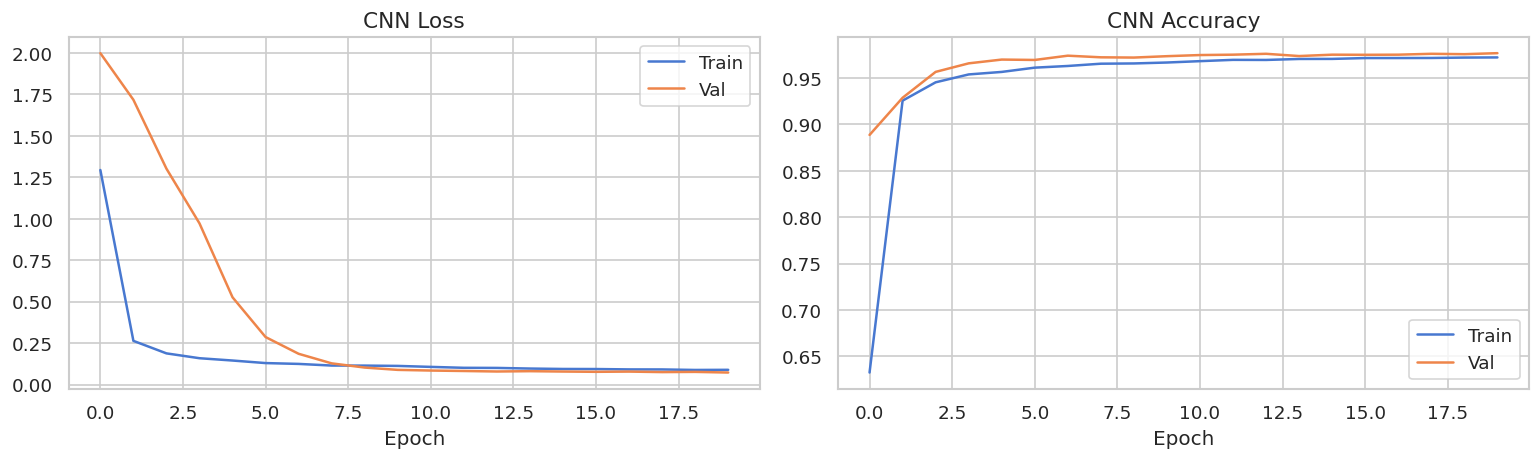

In [37]:
# CNN learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(cnn_hist.history["loss"], label="Train")
axes[0].plot(cnn_hist.history["val_loss"], label="Val")
axes[0].set_title("CNN Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(cnn_hist.history["accuracy"], label="Train")
axes[1].plot(cnn_hist.history["val_accuracy"], label="Val")
axes[1].set_title("CNN Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

In [38]:
# Evaluate CNN on test set
t0 = time.time()
cnn_prob = cnn.predict(X_te3, batch_size=BATCH, verbose=0)
cnn_lat  = (time.time()-t0)/len(X_te3)*1000

cnn_pred = np.argmax(cnn_prob, axis=1)
cnn_acc  = accuracy_score(y_te, cnn_pred)
cnn_prec = precision_score(y_te, cnn_pred, average="weighted", zero_division=0)
cnn_rec  = recall_score(y_te, cnn_pred, average="weighted", zero_division=0)
cnn_f1   = f1_score(y_te, cnn_pred, average="weighted", zero_division=0)

benign_idx   = list(le.classes_).index("BENIGN")
y_te_binary  = y_binary[len(y_tr)+len(y_val):]
cnn_auc  = roc_auc_score(y_te_binary, 1 - cnn_prob[:, benign_idx])

print(f"CNN  Acc={cnn_acc:.4f}  Prec={cnn_prec:.4f}  Rec={cnn_rec:.4f}  F1={cnn_f1:.4f}  AUC={cnn_auc:.4f}  Lat={cnn_lat:.3f}ms")

CNN  Acc=0.9756  Prec=0.9781  Rec=0.9756  F1=0.9722  AUC=0.5062  Lat=0.144ms


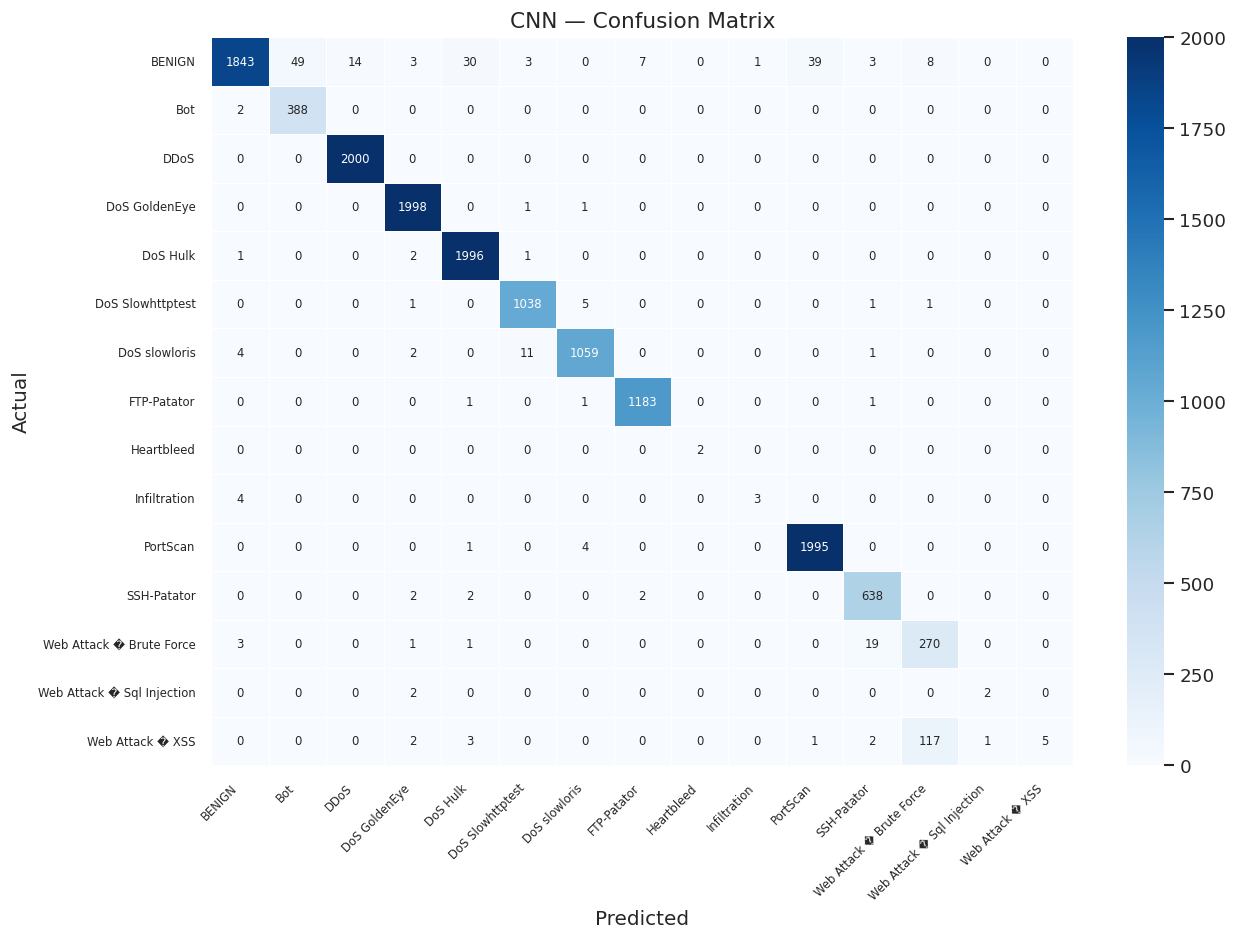

In [39]:

# CNN Confusion Matrix
cm = confusion_matrix(y_te, cnn_pred)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.3, annot_kws={"size":7})
ax.set_title("CNN — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.xticks(rotation=45, ha="right", fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()


In [40]:
# CNN Classification Report
print("CNN Classification Report\n")
print(classification_report(y_te, cnn_pred, target_names=le.classes_, zero_division=0))


CNN Classification Report

                            precision    recall  f1-score   support

                    BENIGN       0.99      0.92      0.96      2000
                       Bot       0.89      0.99      0.94       390
                      DDoS       0.99      1.00      1.00      2000
             DoS GoldenEye       0.99      1.00      1.00      2000
                  DoS Hulk       0.98      1.00      0.99      2000
          DoS Slowhttptest       0.98      0.99      0.99      1046
             DoS slowloris       0.99      0.98      0.99      1077
               FTP-Patator       0.99      1.00      0.99      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.75      0.43      0.55         7
                  PortScan       0.98      1.00      0.99      2000
               SSH-Patator       0.96      0.99      0.97       644
  Web Attack � Brute Force       0.68      0.92      0.78       294
Web Attack � Sql Inj

### 7B. Long Short-Term Memory (LSTM)

In [41]:
# Build LSTM
lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(n_features, 1)),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
], name="LSTM")
lstm.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
lstm.summary()


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 68, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 68, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 68, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,871 (476.06 KB)

 Trainable params: 121,487 (474.56 KB)

 Non-trainable params: 384 (1.50 KB)

In [42]:
# Train LSTM
t0 = time.time()
lstm_hist = lstm.fit(X_tr3, y_tr_cat,
                     validation_data=(X_val3, y_val_cat),
                     epochs=EPOCHS, batch_size=BATCH,
                     callbacks=[es, rlr], verbose=1)
lstm_train_t = time.time() - t0
print(f"LSTM training time: {lstm_train_t:.1f}s")


Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.4177 - loss: 1.8629 - val_accuracy: 0.2391 - val_loss: 2.3529 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7289 - loss: 0.8793 - val_accuracy: 0.4115 - val_loss: 2.0212 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8480 - loss: 0.5315 - val_accuracy: 0.4464 - val_loss: 1.7828 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8834 - loss: 0.4053 - val_accuracy: 0.5011 - val_loss: 1.6466 - learning_rate: 5.0000e-04
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8985 - loss: 0.3485 - val_accuracy: 0.6359 - val_loss: 1.2947 - learning_rate: 5.0000e-04
LSTM training time: 18.5s


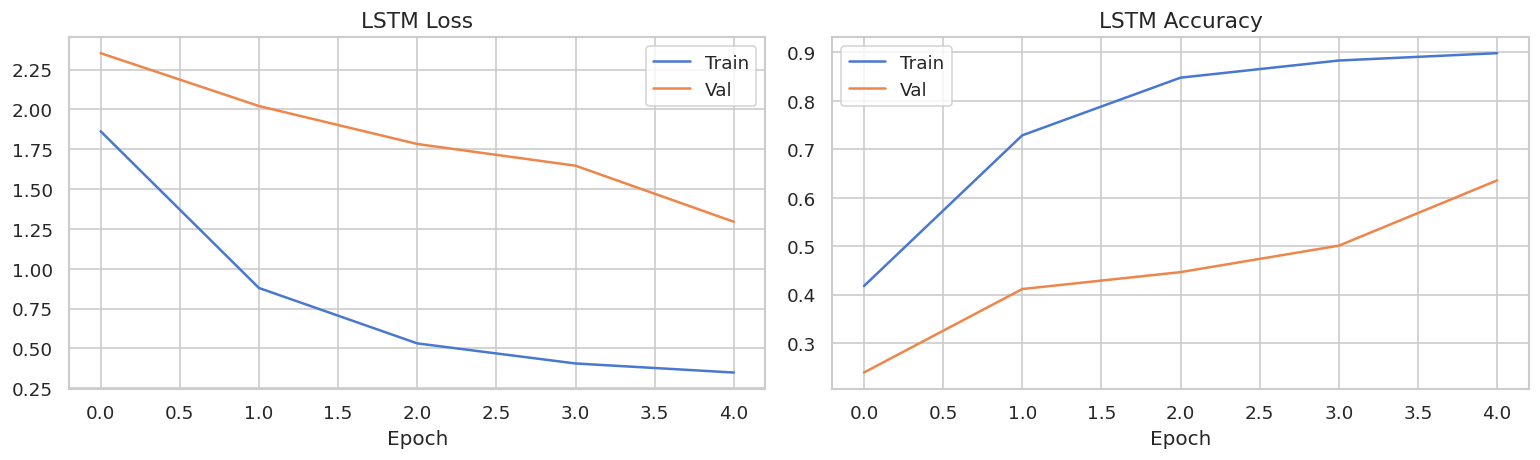

In [43]:
# LSTM learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lstm_hist.history["loss"], label="Train")
axes[0].plot(lstm_hist.history["val_loss"], label="Val")
axes[0].set_title("LSTM Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(lstm_hist.history["accuracy"], label="Train")
axes[1].plot(lstm_hist.history["val_accuracy"], label="Val")
axes[1].set_title("LSTM Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

In [44]:
# Evaluate LSTM
t0 = time.time()
lstm_prob = lstm.predict(X_te3, batch_size=BATCH, verbose=0)
lstm_lat  = (time.time()-t0)/len(X_te3)*1000

lstm_pred = np.argmax(lstm_prob, axis=1)
lstm_acc  = accuracy_score(y_te, lstm_pred)
lstm_prec = precision_score(y_te, lstm_pred, average="weighted", zero_division=0)
lstm_rec  = recall_score(y_te, lstm_pred, average="weighted", zero_division=0)
lstm_f1   = f1_score(y_te, lstm_pred, average="weighted", zero_division=0)
lstm_auc  = roc_auc_score(y_te_binary, 1 - lstm_prob[:, benign_idx])

print(f"LSTM Acc={lstm_acc:.4f}  Prec={lstm_prec:.4f}  Rec={lstm_rec:.4f}  F1={lstm_f1:.4f}  AUC={lstm_auc:.4f}  Lat={lstm_lat:.3f}ms")


LSTM Acc=0.2410  Prec=0.1607  Rec=0.2410  F1=0.1271  AUC=0.5031  Lat=0.042ms


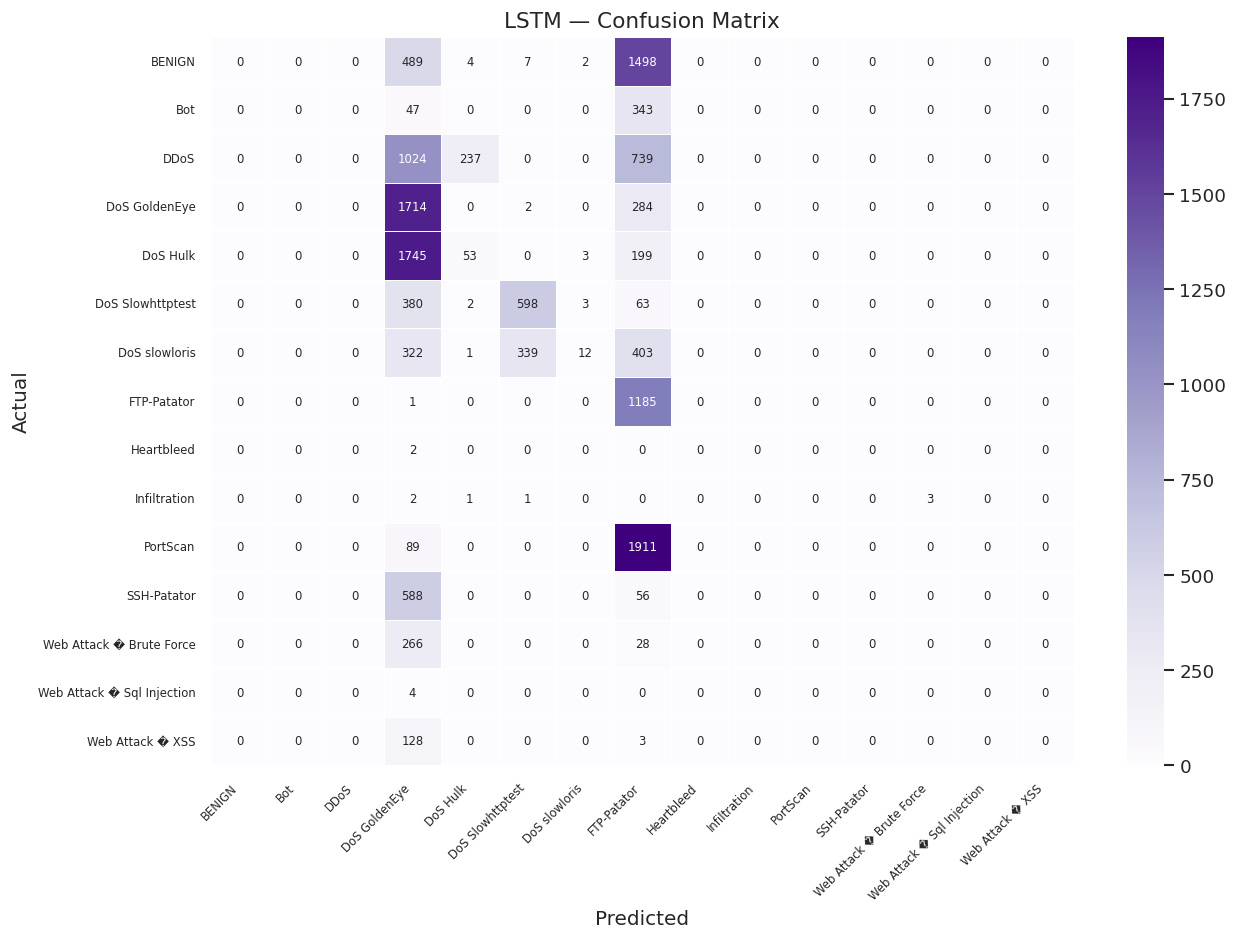

In [45]:
# LSTM Confusion Matrix
cm_l = confusion_matrix(y_te, lstm_pred)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm_l, annot=True, fmt="d", cmap="Purples",
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.3, annot_kws={"size":7})
ax.set_title("LSTM — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.xticks(rotation=45, ha="right", fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()


In [46]:
print("LSTM Classification Report\n")
print(classification_report(y_te, lstm_pred, target_names=le.classes_, zero_division=0))

LSTM Classification Report

                            precision    recall  f1-score   support

                    BENIGN       0.00      0.00      0.00      2000
                       Bot       0.00      0.00      0.00       390
                      DDoS       0.00      0.00      0.00      2000
             DoS GoldenEye       0.25      0.86      0.39      2000
                  DoS Hulk       0.18      0.03      0.05      2000
          DoS Slowhttptest       0.63      0.57      0.60      1046
             DoS slowloris       0.60      0.01      0.02      1077
               FTP-Patator       0.18      1.00      0.30      1186
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.00      0.00      0.00      2000
               SSH-Patator       0.00      0.00      0.00       644
  Web Attack � Brute Force       0.00      0.00      0.00       294
Web Attack � Sql In

### 7C. Transformer-Based Model

In [47]:
# Build Transformer encoder block
inp = Input(shape=(n_features, 1))
x   = Dense(64)(inp)                                   # project to d_model=64

# Multi-Head Attention
attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
attn = Dropout(0.2)(attn)
x    = LayerNormalization()(Add()([x, attn]))

# Feed-Forward
ff = Dense(128, activation="relu")(x)
ff = Dense(64)(ff)
ff = Dropout(0.2)(ff)
x  = LayerNormalization()(Add()([x, ff]))

# Classifier head
x   = GlobalAveragePooling1D()(x)
x   = Dense(64, activation="relu")(x)
x   = Dropout(0.3)(x)
out = Dense(n_classes, activation="softmax")(x)

trans = Model(inputs=inp, outputs=out, name="Transformer")
trans.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
trans.summary()


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 68, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 68, 64)    │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 68, 64)    │     16,640 │ dense_4[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 68, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 68, 64)    │          0 │ dense_4[0][0],    │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 68, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 68, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 68, 64)    │      8,256 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 68, 64)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 68, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 68, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 15)        │        975 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,735 (151.31 KB)

 Trainable params: 38,735 (151.31 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Train Transformer
t0 = time.time()
trans_hist = trans.fit(X_tr3, y_tr_cat,
                       validation_data=(X_val3, y_val_cat),
                       epochs=EPOCHS, batch_size=BATCH,
                       callbacks=[es, rlr], verbose=1)
trans_train_t = time.time() - t0
print(f"Transformer training time: {trans_train_t:.1f}s")


Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 235ms/step - accuracy: 0.3254 - loss: nan - val_accuracy: 0.3861 - val_loss: 1.6700 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4537 - loss: nan - val_accuracy: 0.5870 - val_loss: 1.3772 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5634 - loss: nan - val_accuracy: 0.6263 - val_loss: 1.1586 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6316 - loss: nan - val_accuracy: 0.6870 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6576 - loss: nan - val_accuracy: 0.6798 - val_loss: nan - learning_rate: 5.0000e-04
Transformer training time: 27.5s


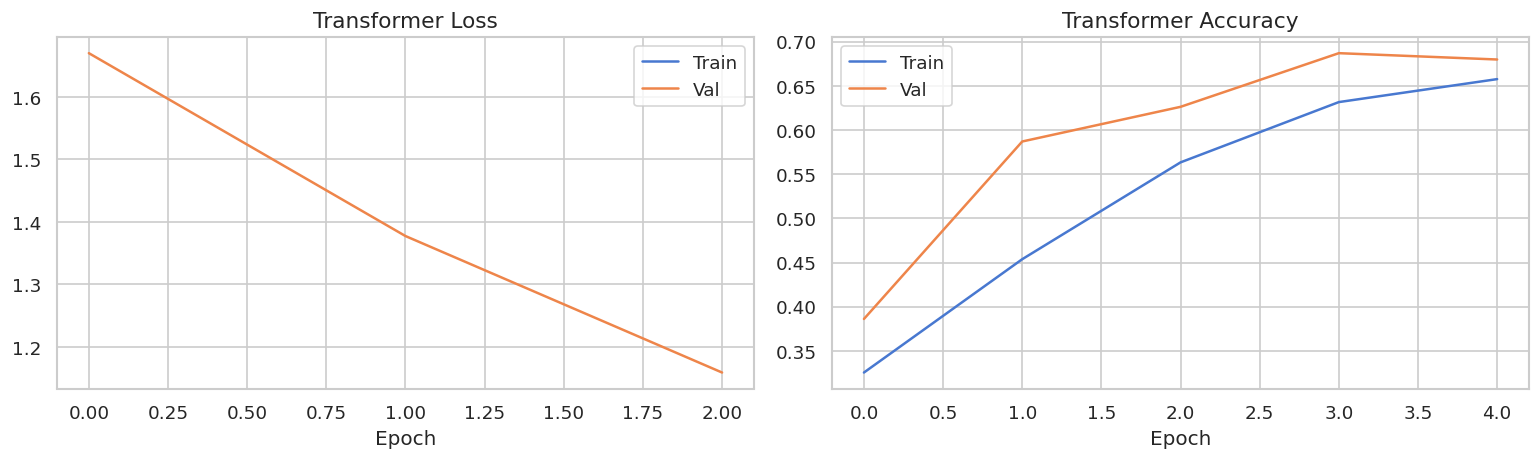

In [49]:
# Transformer learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(trans_hist.history["loss"], label="Train")
axes[0].plot(trans_hist.history["val_loss"], label="Val")
axes[0].set_title("Transformer Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(trans_hist.history["accuracy"], label="Train")
axes[1].plot(trans_hist.history["val_accuracy"], label="Val")
axes[1].set_title("Transformer Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


In [53]:
import numpy as np
# Evaluate Transformer
t0 = time.time()
trans_prob = trans.predict(X_te3, batch_size=BATCH, verbose=0)
trans_lat  = (time.time()-t0)/len(X_te3)*1000

trans_pred = np.argmax(trans_prob, axis=1)
trans_acc  = accuracy_score(y_te, trans_pred)
trans_prec = precision_score(y_te, trans_pred, average="weighted", zero_division=0)
trans_rec  = recall_score(y_te, trans_pred, average="weighted", zero_division=0)
trans_f1   = f1_score(y_te, trans_pred, average="weighted", zero_division=0)

# Handle potential NaN values in trans_prob before calculating AUC
trans_prob_cleaned = np.nan_to_num(trans_prob, nan=0.0)
trans_auc  = roc_auc_score(y_te_binary, 1 - trans_prob_cleaned[:, benign_idx])

print(f"Transformer Acc={trans_acc:.4f}  Prec={trans_prec:.4f}  Rec={trans_rec:.4f}  F1={trans_f1:.4f}  AUC={trans_auc:.4f}  Lat={trans_lat:.3f}ms")

Transformer Acc=0.3887  Prec=0.3295  Rec=0.3887  F1=0.2903  AUC=0.5052  Lat=0.014ms


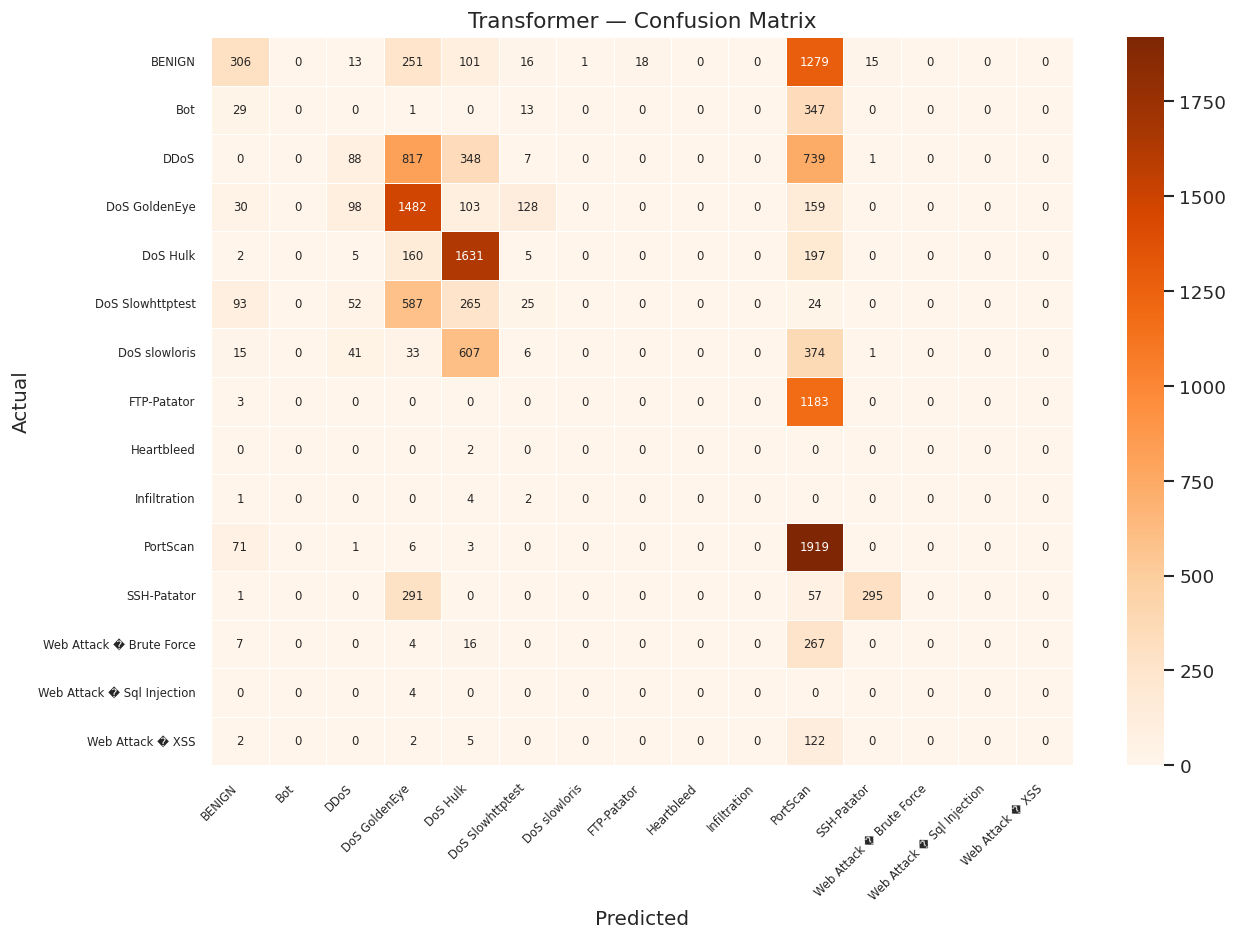

In [54]:
# Transformer Confusion Matrix
cm_t = confusion_matrix(y_te, trans_pred)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm_t, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.3, annot_kws={"size":7})
ax.set_title("Transformer — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.xticks(rotation=45, ha="right", fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()


In [55]:
# Classification report
print("Transformer Classification Report\n")
print(classification_report(y_te, trans_pred, target_names=le.classes_, zero_division=0))

Transformer Classification Report

                            precision    recall  f1-score   support

                    BENIGN       0.55      0.15      0.24      2000
                       Bot       0.00      0.00      0.00       390
                      DDoS       0.30      0.04      0.08      2000
             DoS GoldenEye       0.41      0.74      0.53      2000
                  DoS Hulk       0.53      0.82      0.64      2000
          DoS Slowhttptest       0.12      0.02      0.04      1046
             DoS slowloris       0.00      0.00      0.00      1077
               FTP-Patator       0.00      0.00      0.00      1186
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.29      0.96      0.44      2000
               SSH-Patator       0.95      0.46      0.62       644
  Web Attack � Brute Force       0.00      0.00      0.00       294
Web Attack �

## 8. Explainable AI (XAI)

### 8A. SHAP (CNN)

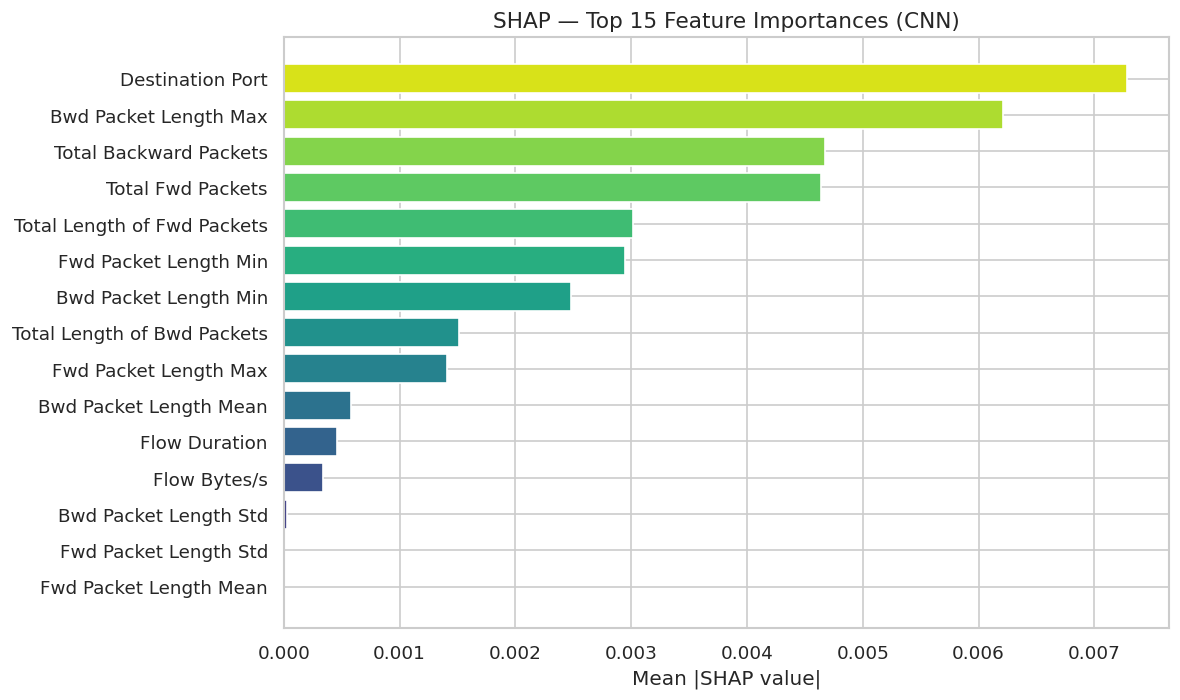

In [61]:
# Clean global variables to ensure no NaNs/Infs persist in the training/test arrays
X_tr = np.nan_to_num(X_tr)
X_te = np.nan_to_num(X_te)

# Wrap CNN with 2-D input for SHAP compatibility
# Removed the Lambda layer as it causes 'shap_SelectV2' lookup errors
shap_wrapper = tf.keras.Sequential([
    tf.keras.layers.Reshape((n_features, 1), input_shape=(n_features,)),
    cnn
])

# Explicitly build the model to define its inputs before passing to SHAP explainer
shap_wrapper.build(input_shape=(None, n_features))
shap_wrapper.compile(optimizer="adam", loss="categorical_crossentropy")

# Background & test samples (2-D)
X_shap_bg   = X_tr[:100] # Reduced to 100 for speed
X_shap_test = X_te[:50]  # Reduced to 50 for speed
feat_names  = list(X.columns)

# SHAP DeepExplainer
explainer  = shap.DeepExplainer(shap_wrapper, X_shap_bg)
shap_vals  = explainer.shap_values(X_shap_test)

# Mean absolute SHAP across classes
mean_shap = np.abs(np.array(shap_vals)).mean(axis=(0, 1))
top15_idx = np.argsort(mean_shap)[-15:]

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([feat_names[i] for i in top15_idx], mean_shap[top15_idx],
        color=sns.color_palette("viridis", 15))
ax.set_title("SHAP — Top 15 Feature Importances (CNN)")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout(); plt.show()

### 8B. LIME (Local Explanation — CNN)

Predicted class: DoS Hulk


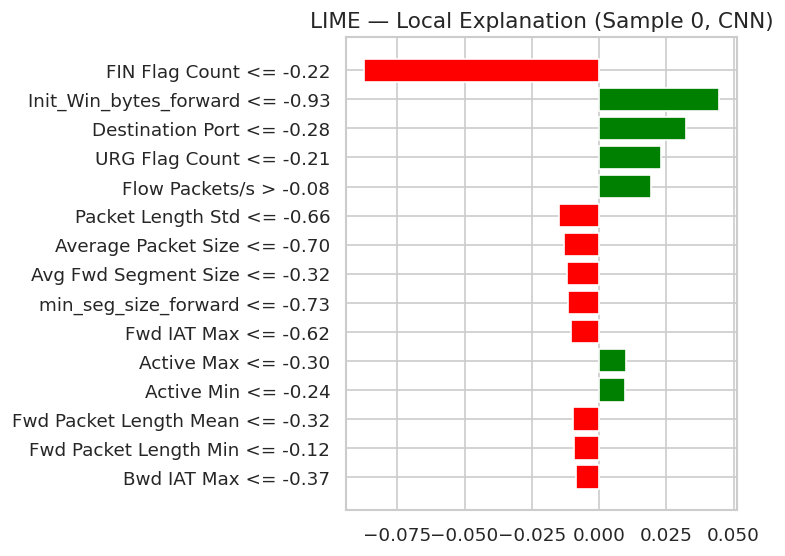

In [73]:
# Predict function that accepts 2-D array and returns probability array
def cnn_pred_fn(x):
    return cnn.predict(x.reshape(-1, n_features, 1), verbose=0)

lime_exp_obj = LimeTabularExplainer(
    training_data=X_shap_bg,
    feature_names=feat_names,
    class_names=list(le.classes_),
    mode="classification",
    random_state=42
)

# Explain a single test sample
exp = lime_exp_obj.explain_instance(
    X_shap_test[0], cnn_pred_fn, num_features=15, top_labels=1)

lbl = exp.top_labels[0]
print(f"Predicted class: {le.classes_[lbl]}")
exp.as_pyplot_figure(label=lbl)
plt.title("LIME — Local Explanation (Sample 0, CNN)")
plt.tight_layout(); plt.show()


## 9. Adversarial Robustness

In [74]:
# Wrap CNN model for ART
art_clf = ARTKeras(
    model=shap_wrapper,
    clip_values=(float(X_te.min()), float(X_te.max())),
    use_logits=False
)

# Small evaluation subset
adv_idx  = np.random.choice(len(X_te), 1000, replace=False)
X_adv_in = X_te[adv_idx]
y_adv_in = y_te[adv_idx]

# Baseline clean accuracy
base_pred = np.argmax(art_clf.predict(X_adv_in), axis=1)
base_acc  = accuracy_score(y_adv_in, base_pred)
print(f"Clean accuracy (subset): {base_acc:.4f}")


Clean accuracy (subset): 0.9790


In [75]:
# FGSM attack at multiple epsilon values
fgsm_eps  = [0.01, 0.05, 0.10, 0.20]
fgsm_accs = []
for eps in fgsm_eps:
    X_adv = FastGradientMethod(estimator=art_clf, eps=eps).generate(X_adv_in)
    acc   = accuracy_score(y_adv_in, np.argmax(art_clf.predict(X_adv), axis=1))
    fgsm_accs.append(acc)
    print(f"  FGSM eps={eps:.2f}  Accuracy={acc:.4f}")


  FGSM eps=0.01  Accuracy=0.9770
  FGSM eps=0.05  Accuracy=0.9090
  FGSM eps=0.10  Accuracy=0.6830
  FGSM eps=0.20  Accuracy=0.4240


In [76]:
# PGD attack at multiple epsilon values
pgd_eps  = [0.01, 0.05, 0.10]
pgd_accs = []
for eps in pgd_eps:
    X_adv = ProjectedGradientDescent(estimator=art_clf, eps=eps,
                                     max_iter=10, verbose=False).generate(X_adv_in)
    acc   = accuracy_score(y_adv_in, np.argmax(art_clf.predict(X_adv), axis=1))
    pgd_accs.append(acc)
    print(f"  PGD  eps={eps:.2f}  Accuracy={acc:.4f}")


  PGD  eps=0.01  Accuracy=0.9750
  PGD  eps=0.05  Accuracy=0.8700
  PGD  eps=0.10  Accuracy=0.5110


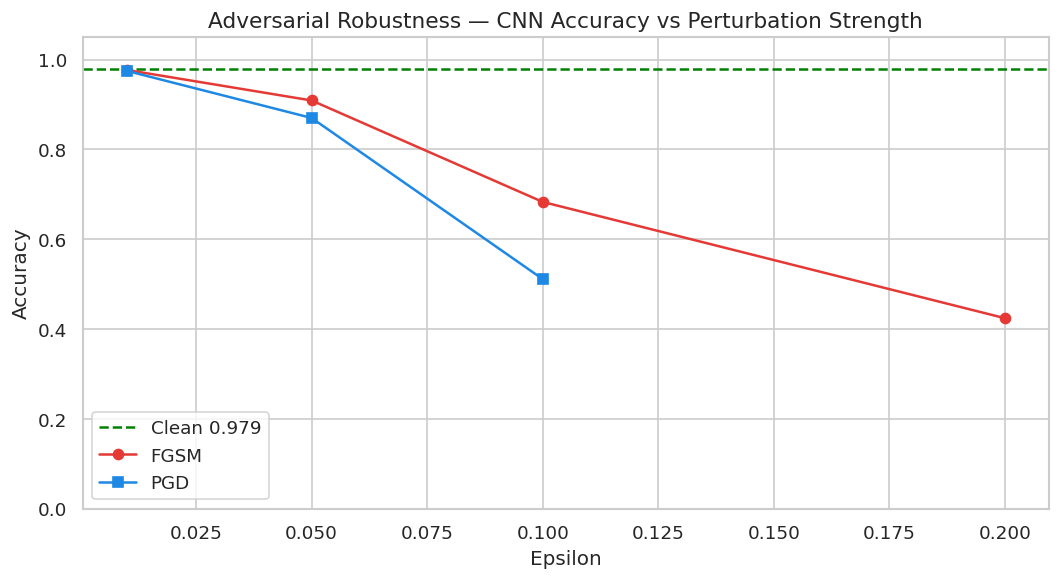

In [77]:
# Robustness curve
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(base_acc, color="green", linestyle="--", lw=1.5, label=f"Clean {base_acc:.3f}")
ax.plot(fgsm_eps, fgsm_accs, "o-", color="#E53935", label="FGSM")
ax.plot(pgd_eps,  pgd_accs,  "s-", color="#1E88E5", label="PGD")
ax.set_title("Adversarial Robustness — CNN Accuracy vs Perturbation Strength")
ax.set_xlabel("Epsilon"); ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.05)
ax.legend(); plt.tight_layout(); plt.show()


## 10. LLM-Powered Autonomous Threat Analysis Agent

In [78]:
# Attack threat profiles (severity + description + mitigation)
THREAT_DB = {
    "BENIGN":      {"sev":"None",     "desc":"Normal traffic.",
                    "mit":"Continue standard monitoring."},
    "DDoS":        {"sev":"Critical", "desc":"Distributed Denial-of-Service flood.",
                    "mit":"Rate-limit source IPs, activate scrubbing, notify NOC."},
    "PortScan":    {"sev":"Medium",   "desc":"Systematic port probe — reconnaissance.",
                    "mit":"Block scanning IP; review firewall rules."},
    "DoS Hulk":    {"sev":"High",     "desc":"HTTP Hulk flood via randomised headers.",
                    "mit":"Enable WAF, rate-limit HTTP endpoints."},
    "Bot":         {"sev":"High",     "desc":"Botnet / C2 communication detected.",
                    "mit":"Quarantine host, scan for malware."},
    "Web Attack":  {"sev":"High",     "desc":"SQLi / XSS / brute-force attempt.",
                    "mit":"Enable WAF, rotate credentials, patch endpoints."},
    "Infiltration":{"sev":"Critical", "desc":"Lateral movement / data exfiltration.",
                    "mit":"Isolate host, capture memory dump, escalate to CISO."},
    "FTP-Patator": {"sev":"Medium",   "desc":"FTP credential brute-force.",
                    "mit":"Lock account, enforce MFA, switch to SFTP."},
    "SSH-Patator": {"sev":"Medium",   "desc":"SSH credential brute-force.",
                    "mit":"Lock account, enforce key-based auth."},
    "Heartbleed":  {"sev":"Critical", "desc":"OpenSSL Heartbleed exploitation attempt.",
                    "mit":"Patch OpenSSL, revoke/reissue TLS certs immediately."},
}

def get_profile(label):
    for key, val in THREAT_DB.items():
        if key.lower() in label.lower():
            return val
    return {"sev":"Unknown","desc":f"Unclassified threat: {label}",
            "mit":"Escalate to tier-2 analyst."}

def threat_report(label, conf, top_feats):
    p = get_profile(label)
    sep = "-"*54
    lines = [
        "=" * 56,
        "   LLM Threat Analysis Agent Report",
        "=" * 56,
        f"  Detected Attack : {label}",
        f"  Severity        : {p['sev']}",
        f"  Confidence      : {conf*100:.1f}%",
        f"  Top Indicators  : {', '.join(top_feats[:4])}",
        sep,
        f"  Analysis   : {p['desc']}",
        sep,
        f"  Mitigation : {p['mit']}",
        "=" * 56,
    ]
    return "\n".join(lines)

# Run on first 5 test predictions
top_shap_features = [feat_names[i] for i in np.argsort(mean_shap)[-5:][::-1]]
for i in range(5):
    label = le.classes_[cnn_pred[i]]
    conf  = cnn_prob[i, cnn_pred[i]]
    print(threat_report(label, conf, top_shap_features))
    print()


   LLM Threat Analysis Agent Report
  Detected Attack : DoS Hulk
  Severity        : High
  Confidence      : 52.3%
  Top Indicators  : Destination Port, Bwd Packet Length Max, Total Backward Packets, Total Fwd Packets
------------------------------------------------------
  Analysis   : HTTP Hulk flood via randomised headers.
------------------------------------------------------
  Mitigation : Enable WAF, rate-limit HTTP endpoints.

   LLM Threat Analysis Agent Report
  Detected Attack : DoS GoldenEye
  Severity        : Unknown
  Confidence      : 99.8%
  Top Indicators  : Destination Port, Bwd Packet Length Max, Total Backward Packets, Total Fwd Packets
------------------------------------------------------
  Analysis   : Unclassified threat: DoS GoldenEye
------------------------------------------------------
  Mitigation : Escalate to tier-2 analyst.

   LLM Threat Analysis Agent Report
  Detected Attack : DDoS
  Severity        : Critical
  Confidence      : 100.0%
  Top Indicat

## 11. Zero-Trust Decision Module

In [79]:
SEV_SCORE = {"None":0,"Low":1,"Medium":2,"High":3,"Critical":4,"Unknown":3}

def zt_decision(label, conf, threshold=0.80):
    p = get_profile(label)
    s = SEV_SCORE.get(p["sev"], 3)
    if label == "BENIGN":
        return "ALLOW" if conf >= threshold else "MONITOR"
    return "RESTRICT" if s <= 2 else "QUARANTINE"

# Print decisions for first 20 test samples
print(f"{'#':>3}  {'Predicted Class':26s}  {'Conf':>6}  Decision")
print("-" * 60)
for i in range(20):
    lbl  = le.classes_[cnn_pred[i]]
    conf = cnn_prob[i, cnn_pred[i]]
    dec  = zt_decision(lbl, conf)
    icon = {"ALLOW":"OK", "MONITOR":"WARN", "RESTRICT":"BLOCK", "QUARANTINE":"QUAR"}
    print(f"{i+1:>3}  {lbl:26s}  {conf:.4f}  [{icon[dec]}] {dec}")


  #  Predicted Class               Conf  Decision
------------------------------------------------------------
  1  DoS Hulk                    0.5234  [QUAR] QUARANTINE
  2  DoS GoldenEye               0.9980  [QUAR] QUARANTINE
  3  DDoS                        1.0000  [QUAR] QUARANTINE
  4  SSH-Patator                 1.0000  [BLOCK] RESTRICT
  5  DoS GoldenEye               1.0000  [QUAR] QUARANTINE
  6  SSH-Patator                 1.0000  [BLOCK] RESTRICT
  7  DDoS                        1.0000  [QUAR] QUARANTINE
  8  BENIGN                      1.0000  [OK] ALLOW
  9  PortScan                    1.0000  [BLOCK] RESTRICT
 10  Web Attack � Brute Force    0.5684  [QUAR] QUARANTINE
 11  DoS Hulk                    1.0000  [QUAR] QUARANTINE
 12  PortScan                    0.9536  [BLOCK] RESTRICT
 13  BENIGN                      1.0000  [OK] ALLOW
 14  DDoS                        1.0000  [QUAR] QUARANTINE
 15  DDoS                        1.0000  [QUAR] QUARANTINE
 16  PortScan         

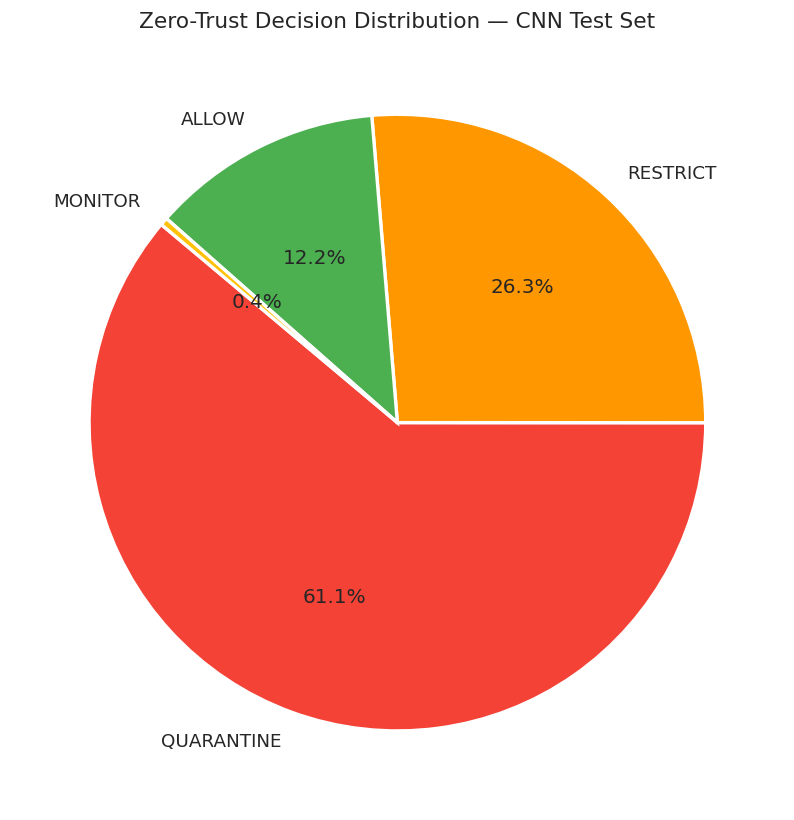

In [80]:
# Zero-Trust decision distribution
from collections import Counter
all_decisions = [zt_decision(le.classes_[p], cnn_prob[i, p]) for i, p in enumerate(cnn_pred)]
dc = Counter(all_decisions)

color_map = {"ALLOW":"#4CAF50","MONITOR":"#FFC107","RESTRICT":"#FF9800","QUARANTINE":"#F44336"}
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(dc.values(), labels=dc.keys(), autopct="%1.1f%%",
       colors=[color_map[k] for k in dc.keys()],
       startangle=140, wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Zero-Trust Decision Distribution — CNN Test Set")
plt.tight_layout(); plt.show()


## 12. Model Comparison

In [81]:
# Summary table using the metrics computed in previous steps
df_cmp = pd.DataFrame({
    "Model"         : ["CNN",      "LSTM",      "Transformer"],
    "Accuracy"      : [cnn_acc,    lstm_acc,    trans_acc],
    "Precision"     : [cnn_prec,   lstm_prec,   trans_prec],
    "Recall"        : [cnn_rec,    lstm_rec,    trans_rec],
    "F1-Score"      : [cnn_f1,     lstm_f1,     trans_f1],
    "ROC-AUC"       : [cnn_auc,    lstm_auc,    trans_auc],
    "Train Time (s)": [cnn_train_t,lstm_train_t,trans_train_t],
    "Latency (ms)"  : [cnn_lat,    lstm_lat,    trans_lat],
}).set_index("Model")

print("="*80)
print(df_cmp.round(4).to_string())
print("="*80)

             Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)  Latency (ms)
Model                                                                                    
CNN            0.9756     0.9781  0.9756    0.9722   0.5062         33.8268        0.1443
LSTM           0.2410     0.1607  0.2410    0.1271   0.5031         18.4877        0.0415
Transformer    0.3887     0.3295  0.3887    0.2903   0.5052         27.5405        0.0139


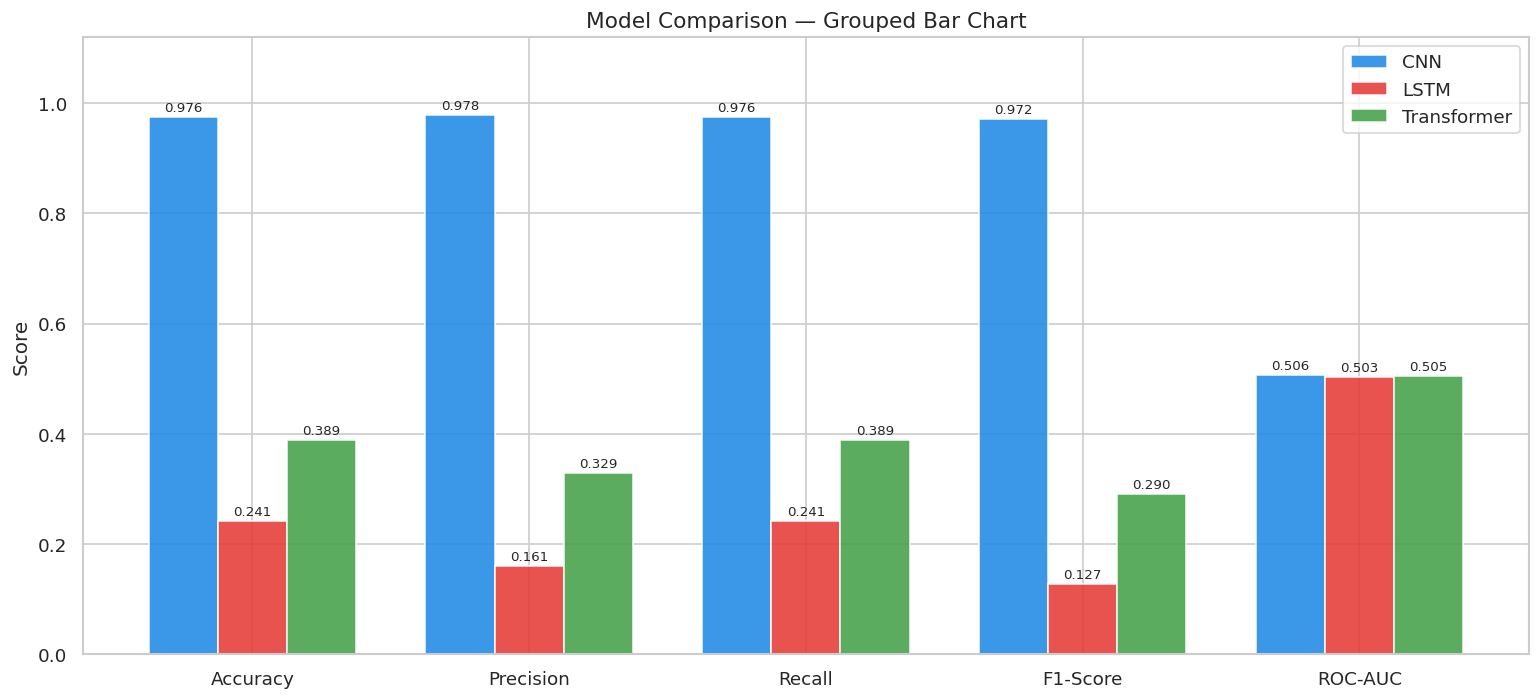

In [82]:
# Grouped bar chart — main metrics
metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
models  = ["CNN","LSTM","Transformer"]
vals    = [
    [cnn_acc,   cnn_prec,   cnn_rec,   cnn_f1,   cnn_auc],
    [lstm_acc,  lstm_prec,  lstm_rec,  lstm_f1,  lstm_auc],
    [trans_acc, trans_prec, trans_rec, trans_f1, trans_auc],
]
colors_m = ["#1E88E5","#E53935","#43A047"]
x = np.arange(len(metrics)); w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (m, v, c) in enumerate(zip(models, vals, colors_m)):
    bars = ax.bar(x + i*w, v, w, label=m, color=c, alpha=0.87, edgecolor="white")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x+w); ax.set_xticklabels(metrics)
ax.set_title("Model Comparison — Grouped Bar Chart")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.12); ax.legend()
plt.tight_layout(); plt.show()


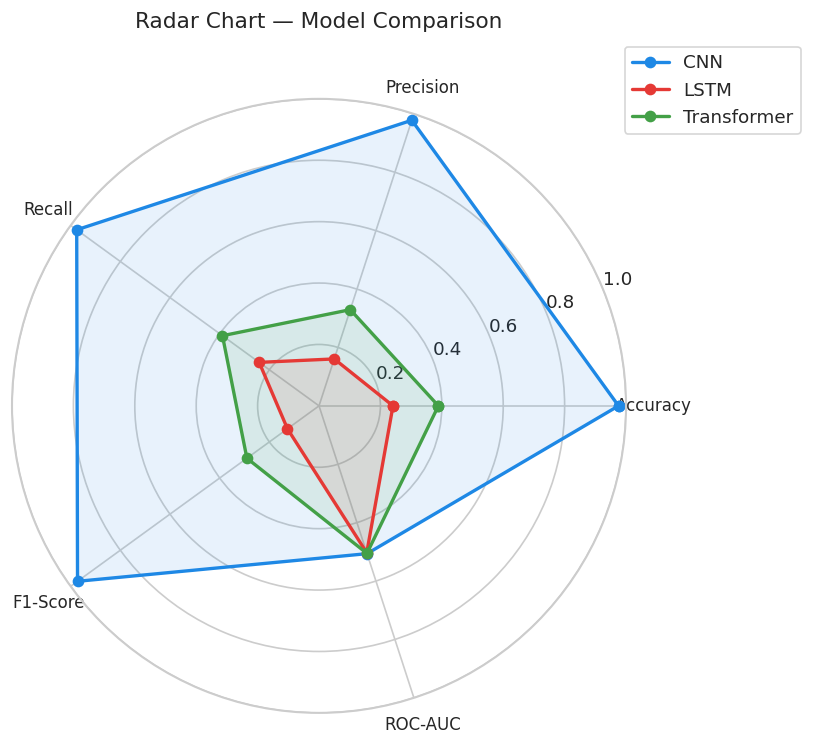

In [83]:

# Radar chart
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for m, v, c in zip(models, vals, colors_m):
    vp = v + v[:1]
    ax.plot(angles, vp, "o-", lw=2, label=m, color=c)
    ax.fill(angles, vp, alpha=0.1, color=c)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Radar Chart — Model Comparison", y=1.1, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()


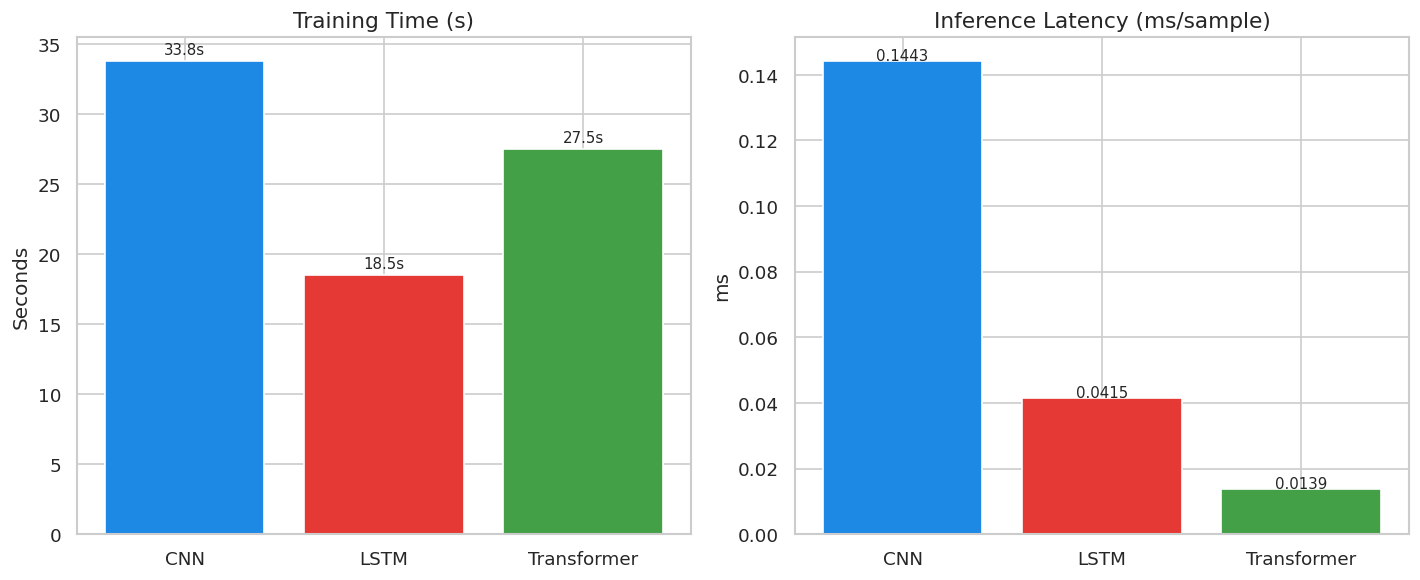

In [84]:
# Train time and latency side-by-side bars
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tt = [cnn_train_t, lstm_train_t, trans_train_t]
lt = [cnn_lat, lstm_lat, trans_lat]
axes[0].bar(models, tt, color=colors_m, edgecolor="white")
for i, v in enumerate(tt): axes[0].text(i, v+0.5, f"{v:.1f}s", ha="center", fontsize=9)
axes[0].set_title("Training Time (s)"); axes[0].set_ylabel("Seconds")
axes[1].bar(models, lt, color=colors_m, edgecolor="white")
for i, v in enumerate(lt): axes[1].text(i, v+0.0001, f"{v:.4f}", ha="center", fontsize=9)
axes[1].set_title("Inference Latency (ms/sample)"); axes[1].set_ylabel("ms")
plt.tight_layout(); plt.show()
